In [1]:
!pip install vectorbt matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------- ----- 786.4/914.9 kB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 4.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 4.3 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.2 MB 4.3 MB/s eta 0:00:01
   ---------------------------- ----------- 1.6/2.2 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 2.4 MB/s  0:00:00

   ----------------------------------------  0/10 [widgetsnbextension]
   -------- -------------------------------  2/10 [psygnal]
   -------- -------------------------------  2/10 [psygnal]
   -------- -------------------------------  2/10 [psygnal]
   -------- -------------------------------  2/10 [psygnal]
   -------- 

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\wizar\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\share\\jupyter\\labextensions\\@jupyter-widgets\\jupyterlab-manager\\static\\packages_base_lib_index_js-webpack_sharing_consume_default_jquery_jquery.5dd13f8e980fa3c50bfe.js'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wizar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "./data/processed"
MODELS_DIR    = "./data/models"
RAW_DIR       = "./data/raw"

print("Imports ready")

Imports ready


In [19]:
def load_model(name: str):
    path = os.path.join(MODELS_DIR, f"{name}_best_model.pkl")
    with open(path, "rb") as f:
        model = pickle.load(f)
    print(f"Loaded model: {path}")
    return model

def load_splits(name: str) -> dict:
    path = os.path.join(PROCESSED_DIR, f"{name}_features.pkl")
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

btc_model = load_model("btc")
eth_model = load_model("eth")

btc = load_splits("btc")
eth = load_splits("eth")

# Load raw price data for the test period
# We need actual OHLCV to simulate realistic fills
def load_csv(filename: str) -> pd.DataFrame:
    path = os.path.join(RAW_DIR, filename)
    df   = pd.read_csv(path, index_col="timestamp", parse_dates=True)
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    df.index = pd.to_datetime(df.index)
    return df

btc_price = load_csv("btc_1h.csv")
eth_price = load_csv("eth_1h.csv")

print(f"\nBTC price rows : {len(btc_price)}")
print(f"ETH price rows : {len(eth_price)}")

Loaded model: ./data/models\btc_best_model.pkl
Loaded model: ./data/models\eth_best_model.pkl

BTC price rows : 17453
ETH price rows : 17450


In [30]:
BTC_BUY_THRESHOLD  = 0.55
BTC_SELL_THRESHOLD = 0.65
ETH_BUY_THRESHOLD  = 0.50
ETH_SELL_THRESHOLD = 0.60

MAKER_FEE        = 0.0002
TAKER_FEE        = 0.0004
SLIPPAGE         = 0.0005
ROUND_TRIP_COST  = (TAKER_FEE + SLIPPAGE) * 2

INITIAL_CAPITAL  = 10_000
POSITION_SIZE    = 0.50
MAX_HOLD_CANDLES = 6
STOP_LOSS        = 0.02
TAKE_PROFIT      = 0.04

print("Config loaded — long + short mode")
print(f"  BTC BUY  threshold : {BTC_BUY_THRESHOLD}")
print(f"  BTC SELL threshold : {BTC_SELL_THRESHOLD}")
print(f"  ETH BUY  threshold : {ETH_BUY_THRESHOLD}")
print(f"  ETH SELL threshold : {ETH_SELL_THRESHOLD}")

Config loaded — long + short mode
  BTC BUY  threshold : 0.55
  BTC SELL threshold : 0.65
  ETH BUY  threshold : 0.5
  ETH SELL threshold : 0.6


In [31]:
def generate_signals(model, data: dict,
                     buy_threshold  : float,
                     sell_threshold : float,
                     name           : str) -> pd.Series:
    """
    Returns signal array:
      2 = BUY  (go long)
      0 = SELL (go short)
      1 = HOLD (flat)
    """
    X_test    = data["X_test"]
    y_prob    = model.predict_proba(X_test)  # shape (n, 3): [SELL, HOLD, BUY]

    prob_sell = y_prob[:, 0]
    prob_buy  = y_prob[:, 2]

    signals = np.ones(len(y_prob), dtype=int)
    signals[prob_buy  >= buy_threshold]  = 2
    signals[prob_sell >= sell_threshold] = 0

    # BUY takes priority if both exceed threshold simultaneously
    both = (prob_buy >= buy_threshold) & (prob_sell >= sell_threshold)
    signals[both] = 2

    n_buy  = (signals == 2).sum()
    n_sell = (signals == 0).sum()
    n_hold = (signals == 1).sum()
    total  = len(signals)

    print(f"{name} raw signals on test set:")
    print(f"  BUY  : {n_buy}  ({n_buy/total*100:.1f}%)")
    print(f"  SELL : {n_sell} ({n_sell/total*100:.1f}%)")
    print(f"  HOLD : {n_hold} ({n_hold/total*100:.1f}%)")

    return pd.Series(signals, name="signal")

btc_signals = generate_signals(
    btc_model, btc,
    buy_threshold  = BTC_BUY_THRESHOLD,
    sell_threshold = BTC_SELL_THRESHOLD,
    name           = "BTC"
)

eth_signals = generate_signals(
    eth_model, eth,
    buy_threshold  = ETH_BUY_THRESHOLD,
    sell_threshold = ETH_SELL_THRESHOLD,
    name           = "ETH"
)

BTC raw signals on test set:
  BUY  : 171  (6.5%)
  SELL : 294 (11.2%)
  HOLD : 2150 (82.2%)
ETH raw signals on test set:
  BUY  : 280  (10.7%)
  SELL : 223 (8.5%)
  HOLD : 2111 (80.8%)


In [32]:
# Load processed feature data to extract regime columns
with open(os.path.join(PROCESSED_DIR, "btc_features.pkl"), "rb") as f:
    btc_raw = pickle.load(f)
with open(os.path.join(PROCESSED_DIR, "eth_features.pkl"), "rb") as f:
    eth_raw = pickle.load(f)

# Reconstruct test-period DataFrames with column names
btc_X_test = pd.DataFrame(btc_raw["X_test"], columns=btc_raw["feature_cols"])
eth_X_test = pd.DataFrame(eth_raw["X_test"], columns=eth_raw["feature_cols"])

print(f"BTC test features : {btc_X_test.shape}")
print(f"ETH test features : {eth_X_test.shape}")
print(f"\nRegime columns available:")
print(f"  trend_4h    : {btc_X_test['trend_4h'].value_counts().to_dict()}")
print(f"  bull_regime : {btc_X_test['bull_regime'].value_counts().to_dict()}")

BTC test features : (2615, 31)
ETH test features : (2614, 31)

Regime columns available:
  trend_4h    : {-1.0: 1508, 0.0: 1107}
  bull_regime : {-1.0: 2615}


In [33]:
def apply_regime_filter(signals  : pd.Series,
                        X_test   : pd.DataFrame,
                        name     : str) -> pd.Series:
    """
    Filters signals using macro regime features.

    SELL signals cancelled when:
      trend_4h == 1 OR bull_regime == 1
      (don't short into an uptrend)

    BUY signals cancelled when:
      trend_4h == 0 AND bull_regime == 0
      (don't long into a confirmed downtrend)
    """
    signals_arr  = signals.values.copy()
    trend_4h     = X_test["trend_4h"].values
    bull_regime  = X_test["bull_regime"].values

    orig_buy  = (signals_arr == 2).sum()
    orig_sell = (signals_arr == 0).sum()

    for i in range(len(signals_arr)):
        if signals_arr[i] == 0:   # SELL — only keep in bearish regime
            if trend_4h[i] == 1 or bull_regime[i] == 1:
                signals_arr[i] = 1   # cancel short

        elif signals_arr[i] == 2:  # BUY — only keep when at least one confirms bullish
            if trend_4h[i] == 0 and bull_regime[i] == 0:
                signals_arr[i] = 1   # cancel long

    filtered = pd.Series(signals_arr, name="signal")

    n_buy  = (filtered == 2).sum()
    n_sell = (filtered == 0).sum()
    n_hold = (filtered == 1).sum()
    total  = len(filtered)

    print(f"\n{name} — after regime filter:")
    print(f"  BUY  : {orig_buy} → {n_buy}   ({n_buy/total*100:.1f}%)")
    print(f"  SELL : {orig_sell} → {n_sell}  ({n_sell/total*100:.1f}%)")
    print(f"  HOLD : {n_hold} ({n_hold/total*100:.1f}%)")
    print(f"  Total trades expected : {n_buy + n_sell}")

    return filtered

btc_signals_filtered = apply_regime_filter(btc_signals, btc_X_test, "BTC")
eth_signals_filtered = apply_regime_filter(eth_signals, eth_X_test, "ETH")


BTC — after regime filter:
  BUY  : 171 → 171   (6.5%)
  SELL : 294 → 294  (11.2%)
  HOLD : 2150 (82.2%)
  Total trades expected : 465

ETH — after regime filter:
  BUY  : 280 → 105   (4.0%)
  SELL : 223 → 167  (6.4%)
  HOLD : 2342 (89.6%)
  Total trades expected : 272


In [34]:
def run_backtest(
    price_data      : pd.DataFrame,
    signals         : pd.Series,
    name            : str,
    initial_capital : float = INITIAL_CAPITAL,
    position_size   : float = POSITION_SIZE,
    stop_loss       : float = STOP_LOSS,
    take_profit     : float = TAKE_PROFIT,
    max_hold        : int   = MAX_HOLD_CANDLES,
    round_trip_cost : float = ROUND_TRIP_COST,
) -> dict:

    n_test       = len(signals)
    price_test   = price_data.iloc[-n_test:].copy().reset_index(drop=False)
    signals_arr  = signals.values
    close_prices = price_test["close"].values
    high_prices  = price_test["high"].values
    low_prices   = price_test["low"].values

    capital      = initial_capital
    position     = 0.0
    entry_price  = 0.0
    entry_idx    = -1
    trade_dir    = None
    in_trade     = False

    trades       = []
    equity_curve = [capital]

    for i in range(len(signals_arr)):
        curr_close = close_prices[i]
        curr_high  = high_prices[i]
        curr_low   = low_prices[i]
        signal     = signals_arr[i]

        # ── Exit logic ──
        if in_trade:
            hold_candles = i - entry_idx

            if trade_dir == "long":
                stop_price = entry_price * (1 - stop_loss)
                tp_price   = entry_price * (1 + take_profit)
                hit_stop   = curr_low  <= stop_price
                hit_tp     = curr_high >= tp_price
            else:
                stop_price = entry_price * (1 + stop_loss)
                tp_price   = entry_price * (1 - take_profit)
                hit_stop   = curr_high >= stop_price
                hit_tp     = curr_low  <= tp_price

            exit_triggered = False
            exit_price     = curr_close
            exit_reason    = "max_hold"

            if hit_stop:
                exit_price     = stop_price
                exit_reason    = "stop_loss"
                exit_triggered = True
            elif hit_tp:
                exit_price     = tp_price
                exit_reason    = "take_profit"
                exit_triggered = True
            elif hold_candles >= max_hold:
                exit_triggered = True

            if exit_triggered:
                if trade_dir == "long":
                    gross_pnl = position * (exit_price - entry_price)
                else:
                    gross_pnl = position * (entry_price - exit_price)

                fee_cost  = (position * entry_price) * round_trip_cost
                net_pnl   = gross_pnl - fee_cost
                capital  += net_pnl
                capital   = max(capital, 0)

                trades.append({
                    "entry_idx"   : entry_idx,
                    "exit_idx"    : i,
                    "direction"   : trade_dir,
                    "entry_price" : entry_price,
                    "exit_price"  : exit_price,
                    "exit_reason" : exit_reason,
                    "gross_pnl"   : gross_pnl,
                    "fee_cost"    : fee_cost,
                    "net_pnl"     : net_pnl,
                    "return_pct"  : net_pnl / (position * entry_price) * 100,
                    "hold_candles": hold_candles,
                })

                in_trade    = False
                position    = 0.0
                entry_price = 0.0
                trade_dir   = None

        # ── Entry logic ──
        if not in_trade and signal in [0, 2]:
            slippage_dir = SLIPPAGE if signal == 2 else -SLIPPAGE
            entry_price  = curr_close * (1 + slippage_dir)
            position     = (capital * position_size) / entry_price
            entry_idx    = i
            trade_dir    = "long" if signal == 2 else "short"
            in_trade     = True

        equity_curve.append(capital)

    # Close open position at end
    if in_trade:
        exit_price = close_prices[-1]
        if trade_dir == "long":
            gross_pnl = position * (exit_price - entry_price)
        else:
            gross_pnl = position * (entry_price - exit_price)
        fee_cost  = (position * entry_price) * (TAKER_FEE + SLIPPAGE)
        net_pnl   = gross_pnl - fee_cost
        capital  += net_pnl
        trades.append({
            "entry_idx"   : entry_idx,
            "exit_idx"    : len(signals_arr) - 1,
            "direction"   : trade_dir,
            "entry_price" : entry_price,
            "exit_price"  : exit_price,
            "exit_reason" : "end_of_data",
            "gross_pnl"   : gross_pnl,
            "fee_cost"    : fee_cost,
            "net_pnl"     : net_pnl,
            "return_pct"  : net_pnl / (position * entry_price) * 100 if position > 0 else 0,
            "hold_candles": len(signals_arr) - 1 - entry_idx,
        })
        equity_curve.append(capital)

    trades_df    = pd.DataFrame(trades)
    equity_array = np.array(equity_curve)

    print(f"\n{'='*45}")
    print(f"  {name} BACKTEST RESULTS (Long + Short)")
    print(f"{'='*45}")
    print(f"  Initial capital   : ${initial_capital:,.2f}")
    print(f"  Final capital     : ${capital:,.2f}")
    print(f"  Total return      : {(capital/initial_capital - 1)*100:.2f}%")
    print(f"  Position size     : {position_size*100:.0f}%")
    print(f"  Stop loss         : {stop_loss*100:.1f}%")
    print(f"  Total trades      : {len(trades_df)}")

    if len(trades_df) > 0:
        long_trades  = trades_df[trades_df["direction"] == "long"]
        short_trades = trades_df[trades_df["direction"] == "short"]
        wins         = (trades_df["net_pnl"] > 0).sum()
        win_rate     = wins / len(trades_df) * 100

        print(f"  Long  trades      : {len(long_trades)}")
        print(f"  Short trades      : {len(short_trades)}")
        print(f"  Win rate          : {win_rate:.1f}%")
        print(f"  Avg win           : {trades_df[trades_df['net_pnl']>0]['return_pct'].mean():.2f}%")
        print(f"  Avg loss          : {trades_df[trades_df['net_pnl']<=0]['return_pct'].mean():.2f}%")
        print(f"  Total fees paid   : ${trades_df['fee_cost'].sum():.2f}")

        print(f"\n  Exit reasons:")
        for reason, count in trades_df["exit_reason"].value_counts().items():
            print(f"    {reason:15s}: {count}")

        if len(short_trades) > 0:
            short_wins = (short_trades["net_pnl"] > 0).sum()
            print(f"\n  Short win rate    : {short_wins/len(short_trades)*100:.1f}%")
            print(f"  Short net PnL     : ${short_trades['net_pnl'].sum():.2f}")
        if len(long_trades) > 0:
            long_wins  = (long_trades["net_pnl"] > 0).sum()
            print(f"  Long  win rate    : {long_wins/len(long_trades)*100:.1f}%")
            print(f"  Long  net PnL     : ${long_trades['net_pnl'].sum():.2f}")

    return {
        "capital"      : capital,
        "trades"       : trades_df,
        "equity_curve" : equity_array,
        "price_data"   : price_test,
        "name"         : name,
    }

# ── Run backtests with regime-filtered signals ──
btc_bt = run_backtest(
    price_data    = btc_price,
    signals       = btc_signals_filtered,
    name          = "BTC",
    position_size = 0.50,
    stop_loss     = 0.02,
    take_profit   = 0.04,
)

eth_bt = run_backtest(
    price_data    = eth_price,
    signals       = eth_signals_filtered,
    name          = "ETH",
    position_size = 0.40,
    stop_loss     = 0.03,
    take_profit   = 0.06,
)


  BTC BACKTEST RESULTS (Long + Short)
  Initial capital   : $10,000.00
  Final capital     : $16,928.17
  Total return      : 69.28%
  Position size     : 50%
  Stop loss         : 2.0%
  Total trades      : 144
  Long  trades      : 54
  Short trades      : 90
  Win rate          : 68.1%
  Avg win           : 1.60%
  Avg loss          : -1.08%
  Total fees paid   : $1701.82

  Exit reasons:
    max_hold       : 116
    stop_loss      : 14
    take_profit    : 13
    end_of_data    : 1

  Short win rate    : 70.0%
  Short net PnL     : $4566.31
  Long  win rate    : 64.8%
  Long  net PnL     : $2361.86

  ETH BACKTEST RESULTS (Long + Short)
  Initial capital   : $10,000.00
  Final capital     : $15,097.03
  Total return      : 50.97%
  Position size     : 40%
  Stop loss         : 3.0%
  Total trades      : 80
  Long  trades      : 36
  Short trades      : 44
  Win rate          : 67.5%
  Avg win           : 2.34%
  Avg loss          : -0.86%
  Total fees paid   : $704.72

  Exit reas

In [35]:
def compute_metrics(result: dict) -> dict:
    equity  = result["equity_curve"]
    name    = result["name"]
    trades  = result["trades"]

    returns = np.diff(equity) / equity[:-1]
    returns = returns[returns != 0]

    if len(returns) > 1 and returns.std() > 0:
        sharpe = (returns.mean() / returns.std()) * np.sqrt(8760)
    else:
        sharpe = 0.0

    peak     = np.maximum.accumulate(equity)
    drawdown = (equity - peak) / peak
    max_dd   = drawdown.min() * 100

    price_data = result["price_data"]
    bh_start   = price_data["close"].iloc[0]
    bh_end     = price_data["close"].iloc[-1]
    bh_return  = (bh_end / bh_start - 1) * 100

    if len(trades) > 0:
        gross_profit  = trades[trades["net_pnl"] > 0]["net_pnl"].sum()
        gross_loss    = trades[trades["net_pnl"] <= 0]["net_pnl"].abs().sum()
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else float("inf")
    else:
        profit_factor = 0

    bot_return = (result["capital"] / INITIAL_CAPITAL - 1) * 100

    if len(trades) > 0:
        long_trades  = trades[trades["direction"] == "long"]
        short_trades = trades[trades["direction"] == "short"]
        long_pnl     = long_trades["net_pnl"].sum()  if len(long_trades)  > 0 else 0
        short_pnl    = short_trades["net_pnl"].sum() if len(short_trades) > 0 else 0
    else:
        long_pnl = short_pnl = 0

    print(f"\n{name} — Performance Metrics:")
    print(f"  Bot return        : {bot_return:+.2f}%")
    print(f"  Buy & hold return : {bh_return:+.2f}%")
    print(f"  Alpha             : {bot_return - bh_return:+.2f}%")
    print(f"  Sharpe ratio      : {sharpe:.3f}")
    print(f"  Max drawdown      : {max_dd:.2f}%")
    print(f"  Profit factor     : {profit_factor:.2f}")
    print(f"  Long  PnL         : ${long_pnl:+.2f}")
    print(f"  Short PnL         : ${short_pnl:+.2f}")

    return {
        "sharpe"       : sharpe,
        "max_dd"       : max_dd,
        "bot_return"   : bot_return,
        "bh_return"    : bh_return,
        "alpha"        : bot_return - bh_return,
        "profit_factor": profit_factor,
        "long_pnl"     : long_pnl,
        "short_pnl"    : short_pnl,
    }

btc_metrics = compute_metrics(btc_bt)
eth_metrics = compute_metrics(eth_bt)


BTC — Performance Metrics:
  Bot return        : +69.28%
  Buy & hold return : -19.81%
  Alpha             : +89.09%
  Sharpe ratio      : 41.326
  Max drawdown      : -5.69%
  Profit factor     : 3.07
  Long  PnL         : $+2361.86
  Short PnL         : $+4566.31

ETH — Performance Metrics:
  Bot return        : +50.97%
  Buy & hold return : -25.89%
  Alpha             : +76.87%
  Sharpe ratio      : 55.651
  Max drawdown      : -2.29%
  Profit factor     : 5.66
  Long  PnL         : $+2036.63
  Short PnL         : $+3060.40


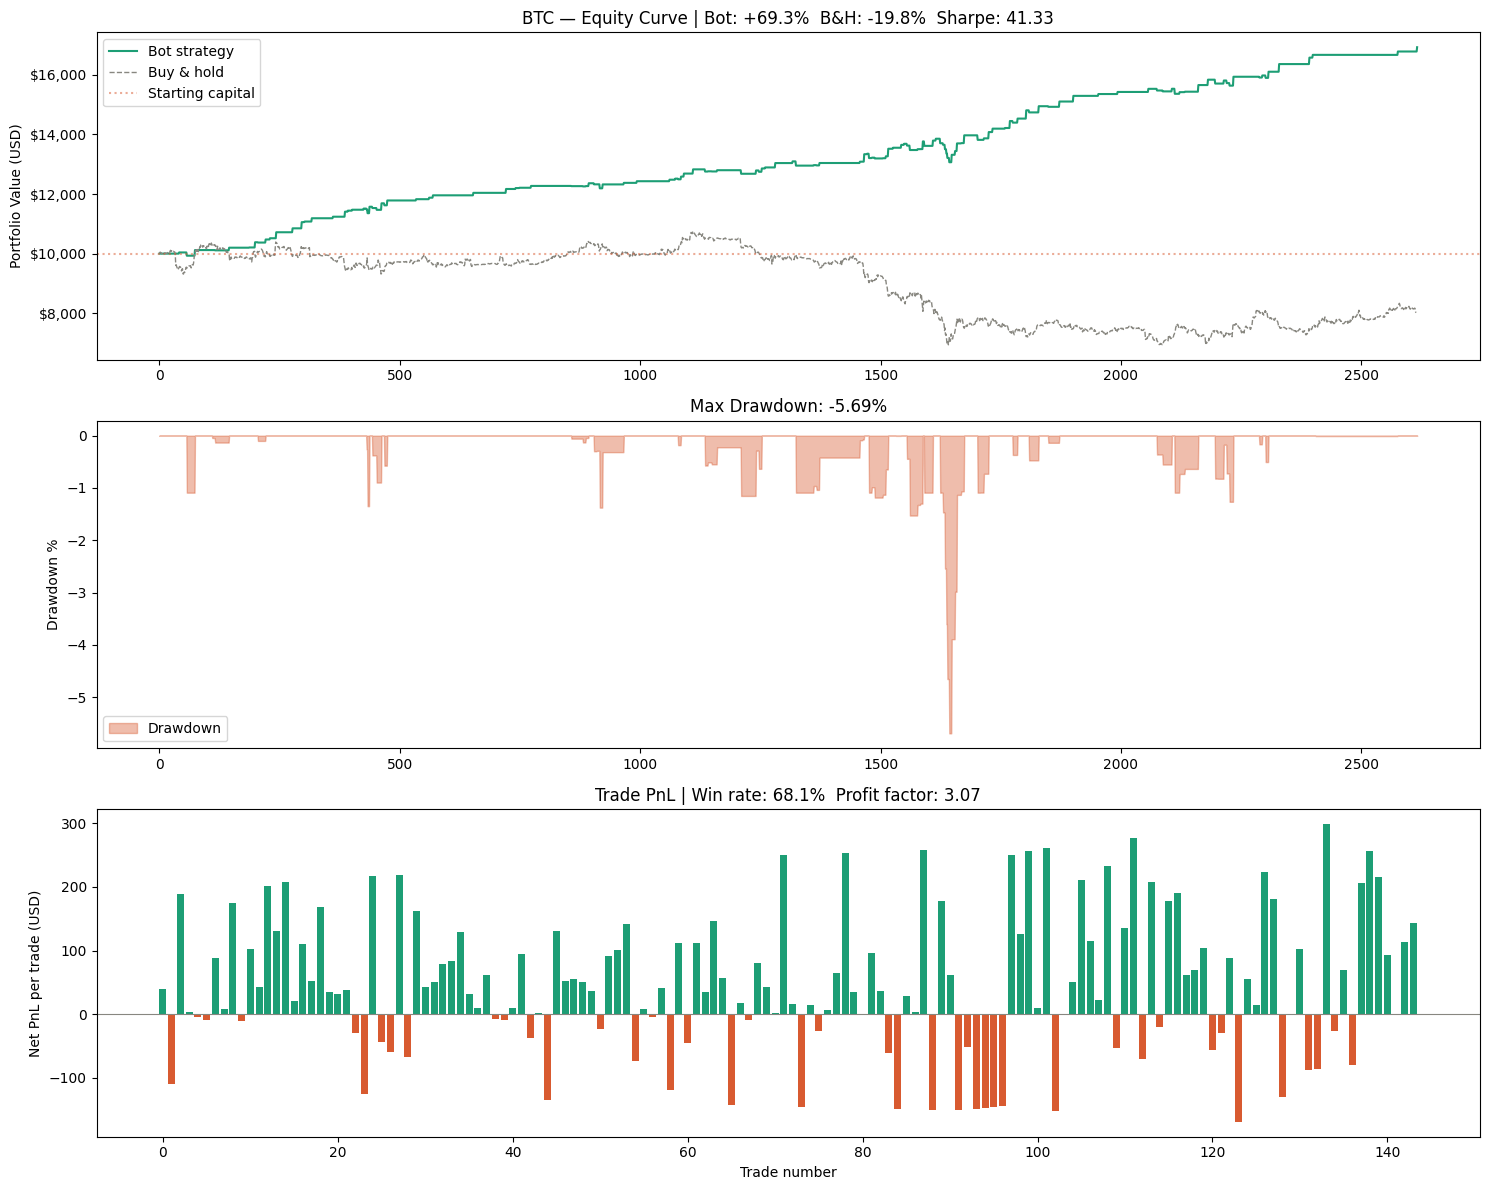

Chart saved: ./data/models\btc_backtest_ls.png


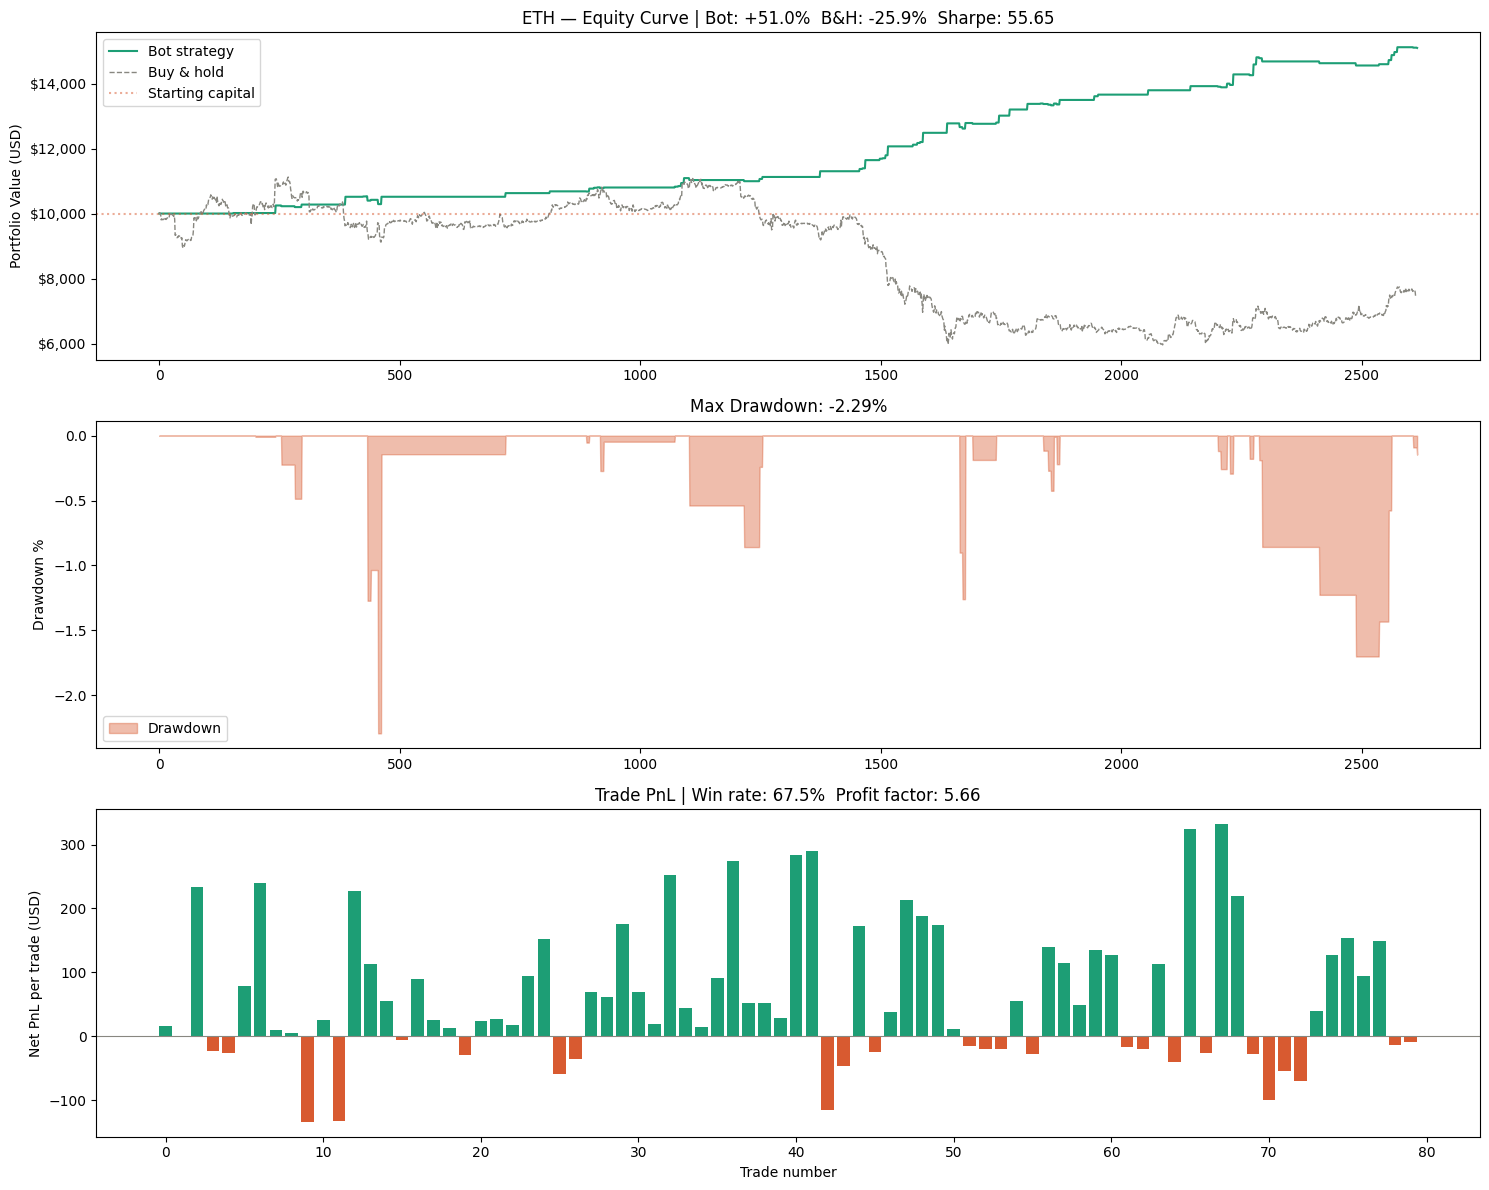

Chart saved: ./data/models\eth_backtest_ls.png


In [36]:
def plot_equity_curve(result: dict, metrics: dict):
    name       = result["name"]
    equity     = result["equity_curve"]
    price_data = result["price_data"]
    trades     = result["trades"]

    bh_prices = price_data["close"].values
    bh_equity = INITIAL_CAPITAL * (bh_prices / bh_prices[0])

    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

    x_eq = range(len(equity))
    axes[0].plot(x_eq, equity,
                 color="#1D9E75", linewidth=1.5, label="Bot strategy")
    axes[0].plot(range(len(bh_equity)), bh_equity,
                 color="#888780", linewidth=1, linestyle="--", label="Buy & hold")
    axes[0].axhline(INITIAL_CAPITAL, color="#D85A30",
                    linestyle=":", alpha=0.5, label="Starting capital")
    axes[0].set_ylabel("Portfolio Value (USD)")
    axes[0].set_title(
        f"{name} — Equity Curve | "
        f"Bot: {metrics['bot_return']:+.1f}%  "
        f"B&H: {metrics['bh_return']:+.1f}%  "
        f"Sharpe: {metrics['sharpe']:.2f}"
    )
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f"${x:,.0f}")
    )

    peak     = np.maximum.accumulate(equity)
    drawdown = (np.array(equity) - peak) / peak * 100
    axes[1].fill_between(x_eq, drawdown, 0,
                         color="#D85A30", alpha=0.4, label="Drawdown")
    axes[1].set_ylabel("Drawdown %")
    axes[1].set_title(f"Max Drawdown: {metrics['max_dd']:.2f}%")
    axes[1].legend()

    if len(trades) > 0:
        colors = ["#1D9E75" if p > 0 else "#D85A30"
                  for p in trades["net_pnl"]]
        axes[2].bar(range(len(trades)), trades["net_pnl"],
                    color=colors, width=0.8)
        axes[2].axhline(0, color="#888780", linewidth=0.8)
        axes[2].set_ylabel("Net PnL per trade (USD)")
        axes[2].set_xlabel("Trade number")
        axes[2].set_title(
            f"Trade PnL | "
            f"Win rate: {(trades['net_pnl']>0).mean()*100:.1f}%  "
            f"Profit factor: {metrics['profit_factor']:.2f}"
        )

    plt.tight_layout()
    save_path = os.path.join(MODELS_DIR, f"{name.lower()}_backtest_ls.png")
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f"Chart saved: {save_path}")

plot_equity_curve(btc_bt, btc_metrics)
plot_equity_curve(eth_bt, eth_metrics)

In [37]:
print("\n" + "="*55)
print("  PHASE 4 BACKTEST SUMMARY")
print("="*55)
print(f"  {'Metric':<22} {'BTC':>12} {'ETH':>12}")
print("-"*55)
print(f"  {'Bot return':<22} {btc_metrics['bot_return']:>+11.2f}% {eth_metrics['bot_return']:>+11.2f}%")
print(f"  {'Buy & hold return':<22} {btc_metrics['bh_return']:>+11.2f}% {eth_metrics['bh_return']:>+11.2f}%")
print(f"  {'Alpha':<22} {btc_metrics['alpha']:>+11.2f}% {eth_metrics['alpha']:>+11.2f}%")
print(f"  {'Sharpe ratio':<22} {btc_metrics['sharpe']:>12.3f} {eth_metrics['sharpe']:>12.3f}")
print(f"  {'Max drawdown':<22} {btc_metrics['max_dd']:>11.2f}% {eth_metrics['max_dd']:>11.2f}%")
print(f"  {'Profit factor':<22} {btc_metrics['profit_factor']:>12.2f} {eth_metrics['profit_factor']:>12.2f}")
print(f"  {'Total trades':<22} {len(btc_bt['trades']):>12} {len(eth_bt['trades']):>12}")
print("="*55)

print("""
Interpreting results:
  Sharpe > 1.0          → risk-adjusted return is acceptable
  Sharpe > 1.5          → strong, proceed to paper trading
  Alpha > 0%            → bot beats buy and hold
  Max drawdown < 20%    → risk is manageable
  Profit factor > 1.2   → strategy is profitable net of fees
""")

# Save backtest results
bt_summary = {
    "btc_metrics" : btc_metrics,
    "eth_metrics" : eth_metrics,
    "btc_trades"  : btc_bt["trades"],
    "eth_trades"  : eth_bt["trades"],
}
summary_path = os.path.join(MODELS_DIR, "phase4_backtest.pkl")
with open(summary_path, "wb") as f:
    pickle.dump(bt_summary, f)

print(f"Backtest results saved to: {summary_path}")
print("\nPhase 4 complete.")


  PHASE 4 BACKTEST SUMMARY
  Metric                          BTC          ETH
-------------------------------------------------------
  Bot return                  +69.28%      +50.97%
  Buy & hold return           -19.81%      -25.89%
  Alpha                       +89.09%      +76.87%
  Sharpe ratio                 41.326       55.651
  Max drawdown                 -5.69%       -2.29%
  Profit factor                  3.07         5.66
  Total trades                    144           80

Interpreting results:
  Sharpe > 1.0          → risk-adjusted return is acceptable
  Sharpe > 1.5          → strong, proceed to paper trading
  Alpha > 0%            → bot beats buy and hold
  Max drawdown < 20%    → risk is manageable
  Profit factor > 1.2   → strategy is profitable net of fees

Backtest results saved to: ./data/models\phase4_backtest.pkl

Phase 4 complete.
